In [2]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [3]:
import os

print(os.listdir('/content'))

['.config', 'train.csv', 'test.csv', 'sample_data']


In [4]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


In [5]:
print(os.listdir('/content'))

['.config', 'train.csv', 'test.csv', 'sample_data']


Train Shape: (1460, 81)
Test Shape: (1459, 80)

First 5 Rows
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSol

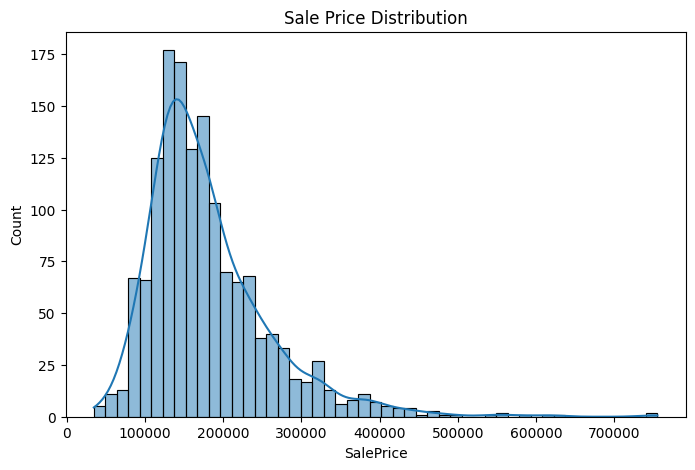


Top Correlated Features with SalePrice
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

Shape After Encoding
(2919, 290)

Linear Regression
RMSE: 29476.125983168968
R2 Score: 0.8867268510481939

Random Forest
RMSE: 29539.301160929426
R2 Score: 0.8862407817468722

XGBoost
RMSE: 25685.089838269985
R2 Score: 0.9139901399612427

Model Comparison
               Model          RMSE  R2 Score
0  Linear Regression  29476.125983  0.886727
1      Random Forest  29539.301161  0.886241
2            XGBoost  25685.089838  0.913990


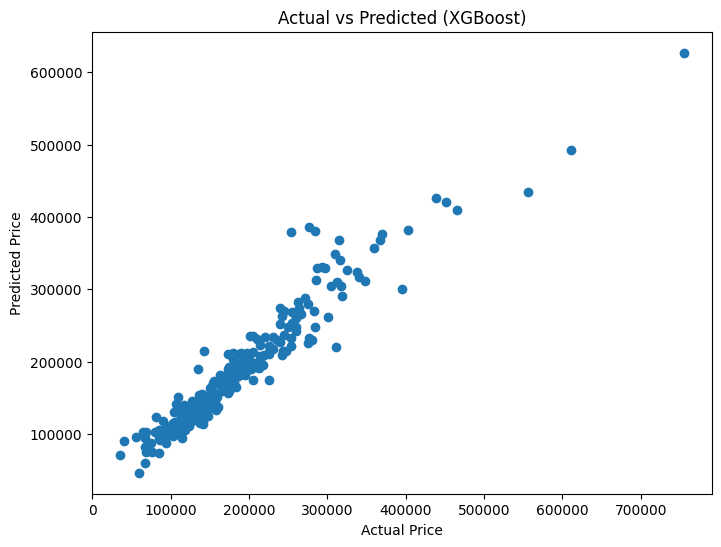

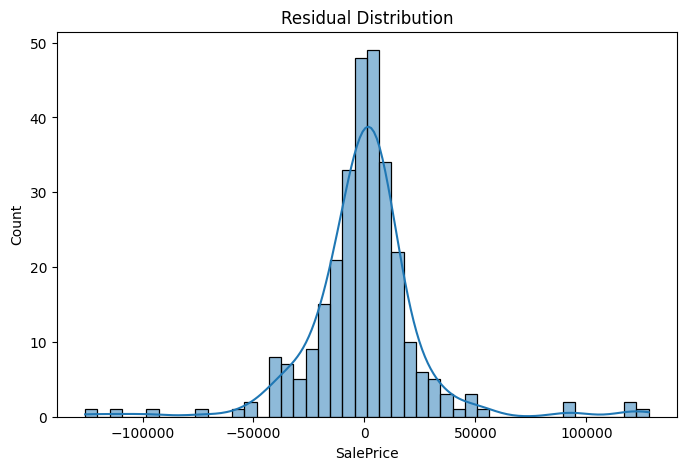

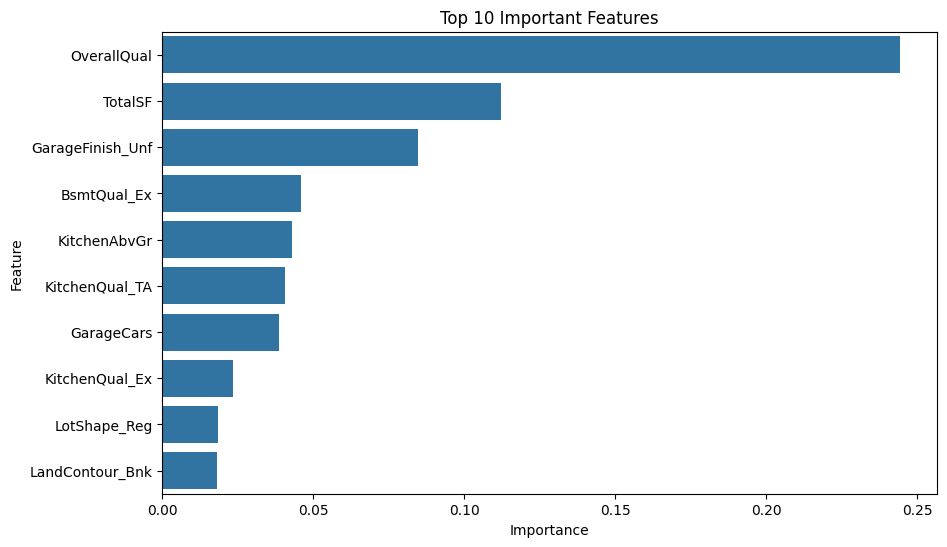


submission.csv generated successfully!
     Id      SalePrice
0  1461  129352.773438
1  1462  171070.546875
2  1463  187388.812500
3  1464  193684.531250
4  1465  188478.062500


In [6]:
# ==========================================
# HOUSE PRICE PREDICTION USING ML
# ==========================================

# Install XGBoost
!pip install -q xgboost

# ==========================================
# Import Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# Load Dataset
# ==========================================

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

# ==========================================
# Dataset Information
# ==========================================

print("\nFirst 5 Rows")
print(train.head())

print("\nDataset Info")
print(train.info())

# ==========================================
# Missing Values
# ==========================================

missing = train.isnull().sum()
missing = missing[missing > 0]

print("\nMissing Values")
print(missing.sort_values(ascending=False))

# ==========================================
# Target Variable Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Sale Price Distribution")
plt.show()

# ==========================================
# Correlation Analysis
# ==========================================

corr_matrix = train.corr(numeric_only=True)

top_corr = corr_matrix["SalePrice"].sort_values(ascending=False)

print("\nTop Correlated Features with SalePrice")
print(top_corr.head(15))

# ==========================================
# Feature Engineering
# ==========================================

train["TotalSF"] = (
    train["TotalBsmtSF"]
    + train["1stFlrSF"]
    + train["2ndFlrSF"]
)

test["TotalSF"] = (
    test["TotalBsmtSF"]
    + test["1stFlrSF"]
    + test["2ndFlrSF"]
)

train["HouseAge"] = 2025 - train["YearBuilt"]
test["HouseAge"] = 2025 - test["YearBuilt"]

# ==========================================
# Save Target Variable
# ==========================================

y = train["SalePrice"]

train.drop("SalePrice", axis=1, inplace=True)

# ==========================================
# Combine Train and Test
# ==========================================

combined = pd.concat([train, test], axis=0)

# ==========================================
# Fill Missing Values
# ==========================================

for col in combined.columns:

    if combined[col].dtype == "object":

        combined[col].fillna(
            combined[col].mode()[0],
            inplace=True
        )

    else:

        combined[col].fillna(
            combined[col].median(),
            inplace=True
        )

# ==========================================
# One-Hot Encoding
# ==========================================

combined = pd.get_dummies(combined)

combined = combined.astype(float)

print("\nShape After Encoding")
print(combined.shape)

# ==========================================
# Split Back
# ==========================================

X = combined.iloc[:len(train), :]
X_test_final = combined.iloc[len(train):, :]

# ==========================================
# Train Test Split
# ==========================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Linear Regression
# ==========================================

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_valid)

rmse_lr = np.sqrt(
    mean_squared_error(y_valid, pred_lr)
)

r2_lr = r2_score(y_valid, pred_lr)

print("\nLinear Regression")
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

# ==========================================
# Random Forest
# ==========================================

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_valid)

rmse_rf = np.sqrt(
    mean_squared_error(y_valid, pred_rf)
)

r2_rf = r2_score(y_valid, pred_rf)

print("\nRandom Forest")
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

# ==========================================
# XGBoost
# ==========================================

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_valid)

rmse_xgb = np.sqrt(
    mean_squared_error(y_valid, pred_xgb)
)

r2_xgb = r2_score(y_valid, pred_xgb)

print("\nXGBoost")
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

# ==========================================
# Model Comparison
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

print("\nModel Comparison")
print(results)

# ==========================================
# Actual vs Predicted
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(y_valid, pred_xgb)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted (XGBoost)")
plt.show()

# ==========================================
# Residual Plot
# ==========================================

residuals = y_valid - pred_xgb

plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.show()

# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

# ==========================================
# Train Final Model
# ==========================================

final_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X, y)

predictions = final_model.predict(X_test_final)

# ==========================================
# Create Submission File
# ==========================================

submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("\nsubmission.csv generated successfully!")
print(submission.head())

In [7]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>